# **1. Perkenalan Dataset**


### Dataset yang Digunakan: Heart Disease Dataset

Dataset yang digunakan dalam eksperimen ini adalah **Heart Disease Dataset** yang diperoleh dari **UCI Machine Learning Repository**.

Dataset ini digunakan untuk memprediksi apakah seorang pasien memiliki indikasi penyakit jantung berdasarkan beberapa fitur klinis, seperti usia, tekanan darah, kadar kolesterol, detak jantung maksimum, dan hasil pemeriksaan lainnya.

Dataset memiliki:

* 303 baris data pasien.
* 13 fitur prediktor.
* 1 kolom target bernama `num`.

Pada dataset asli, nilai target `num` terdiri dari:

* `0`: Tidak terdapat indikasi penyakit jantung.
* `1`, `2`, `3`, atau `4`: Terdapat indikasi penyakit jantung.

Pada eksperimen ini, target akan disederhanakan menjadi klasifikasi biner:

* `0`: Tidak terindikasi penyakit jantung.
* `1`: Terindikasi penyakit jantung.

Sumber dataset: UCI Machine Learning Repository.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
#Type your code here
# Instalasi package untuk mengambil dataset dari UCI Repository
%pip install -U ucimlrepo

In [4]:
# Library untuk pengolahan data
import os
import numpy as np
import pandas as pd

# Library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk preprocessing
from sklearn.preprocessing import StandardScaler

# Library untuk mengambil dataset dari UCI Repository
from ucimlrepo import fetch_ucirepo

# Pengaturan tampilan dataframe dan grafik
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Library berhasil diimpor.")

Library berhasil diimpor.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
# Mengambil dataset Heart Disease dari UCI Repository
heart_disease = fetch_ucirepo(id=45)

# Mengambil fitur dan target
X = heart_disease.data.features
y = heart_disease.data.targets

# Menggabungkan fitur dan target menjadi satu dataframe
df = pd.concat([X, y], axis=1)

print("Dataset berhasil dimuat.")
print("Ukuran dataset:", df.shape)

# Menampilkan lima baris pertama dataset
df.head()

Dataset berhasil dimuat.
Ukuran dataset: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [6]:
print("Daftar kolom dataset:")
print(df.columns.tolist())

Daftar kolom dataset:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [7]:
# Membuat folder penyimpanan dataset mentah
os.makedirs("heart_disease_raw", exist_ok=True)

# Menyimpan dataset mentah ke file CSV
df.to_csv(
    "heart_disease_raw/heart_disease_raw.csv",
    index=False
)

print("Dataset mentah berhasil disimpan.")

Dataset mentah berhasil disimpan.


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [8]:
# Melihat informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [9]:
# Melihat statistik deskriptif dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [10]:
# Memeriksa jumlah missing value pada setiap kolom
missing_values = df.isnull().sum()

print("Jumlah missing value pada setiap kolom:")
print(missing_values)

Jumlah missing value pada setiap kolom:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


In [11]:
# Memeriksa jumlah data duplikat
jumlah_duplikat = df.duplicated().sum()

print("Jumlah data duplikat:", jumlah_duplikat)

Jumlah data duplikat: 0


In [12]:
# Melihat distribusi target asli
print("Distribusi target asli:")
print(df["num"].value_counts().sort_index())

Distribusi target asli:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


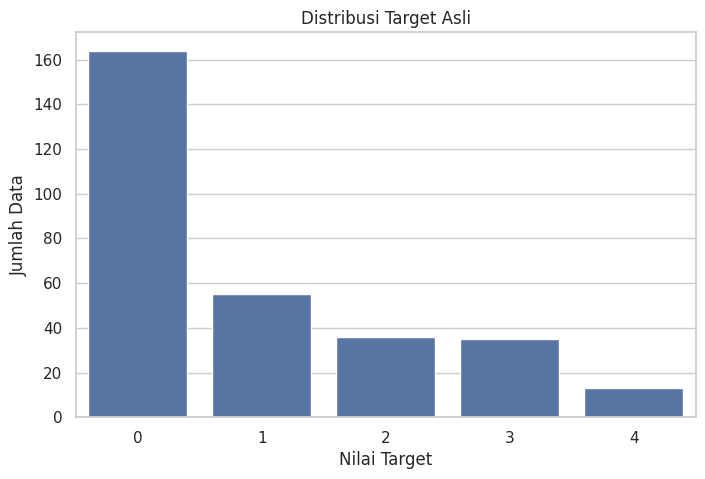

In [13]:
# Visualisasi distribusi target asli
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="num"
)

plt.title("Distribusi Target Asli")
plt.xlabel("Nilai Target")
plt.ylabel("Jumlah Data")
plt.show()

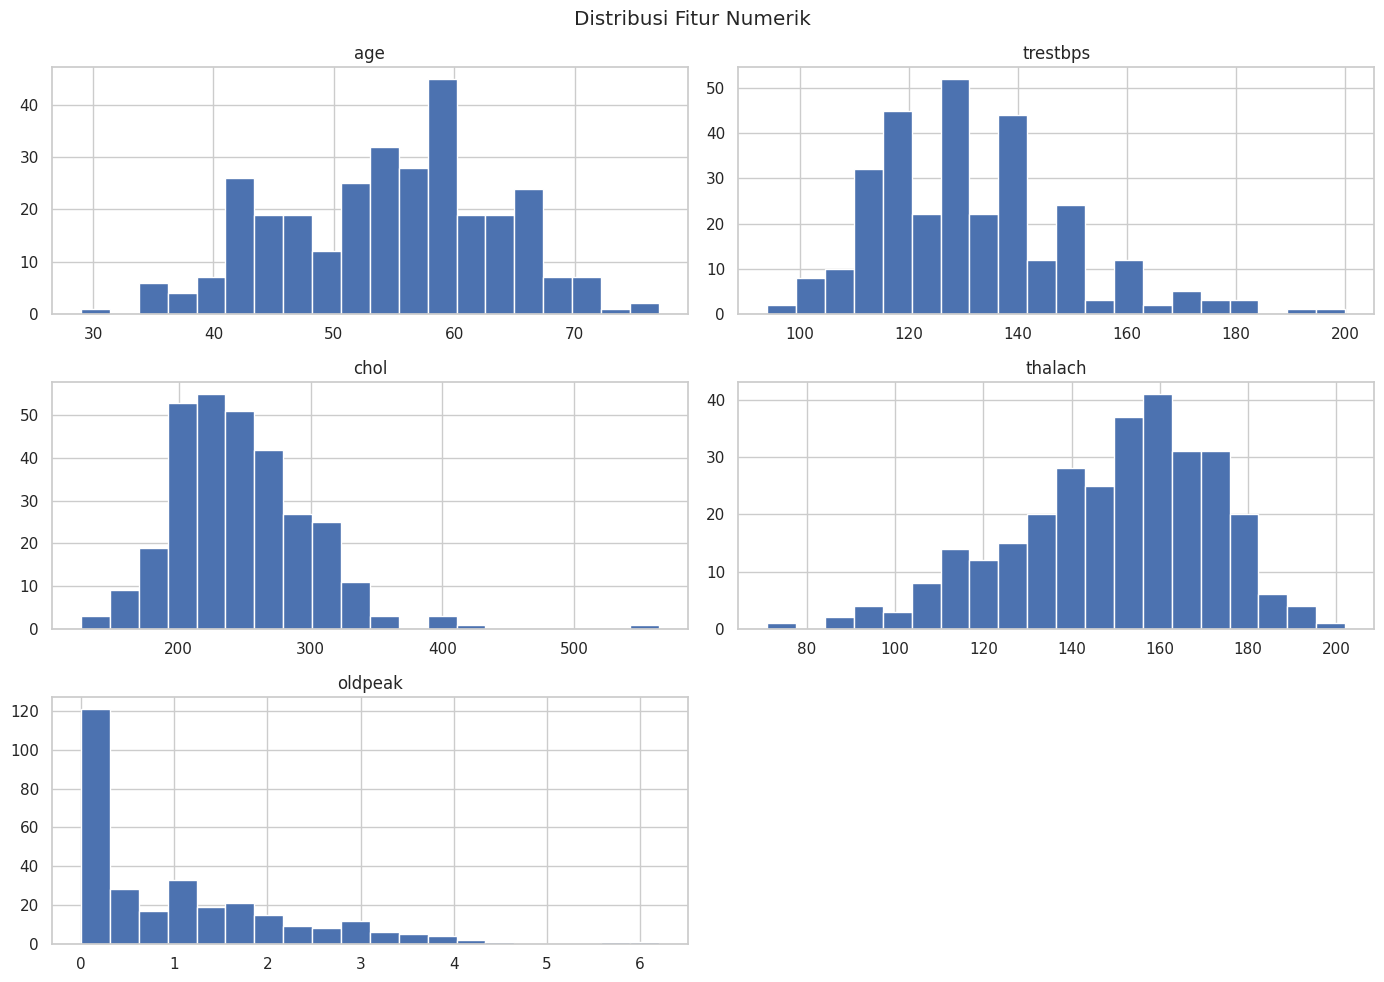

In [14]:
# Melihat distribusi beberapa fitur numerik
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

df[numerical_features].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Distribusi Fitur Numerik")
plt.tight_layout()
plt.show()

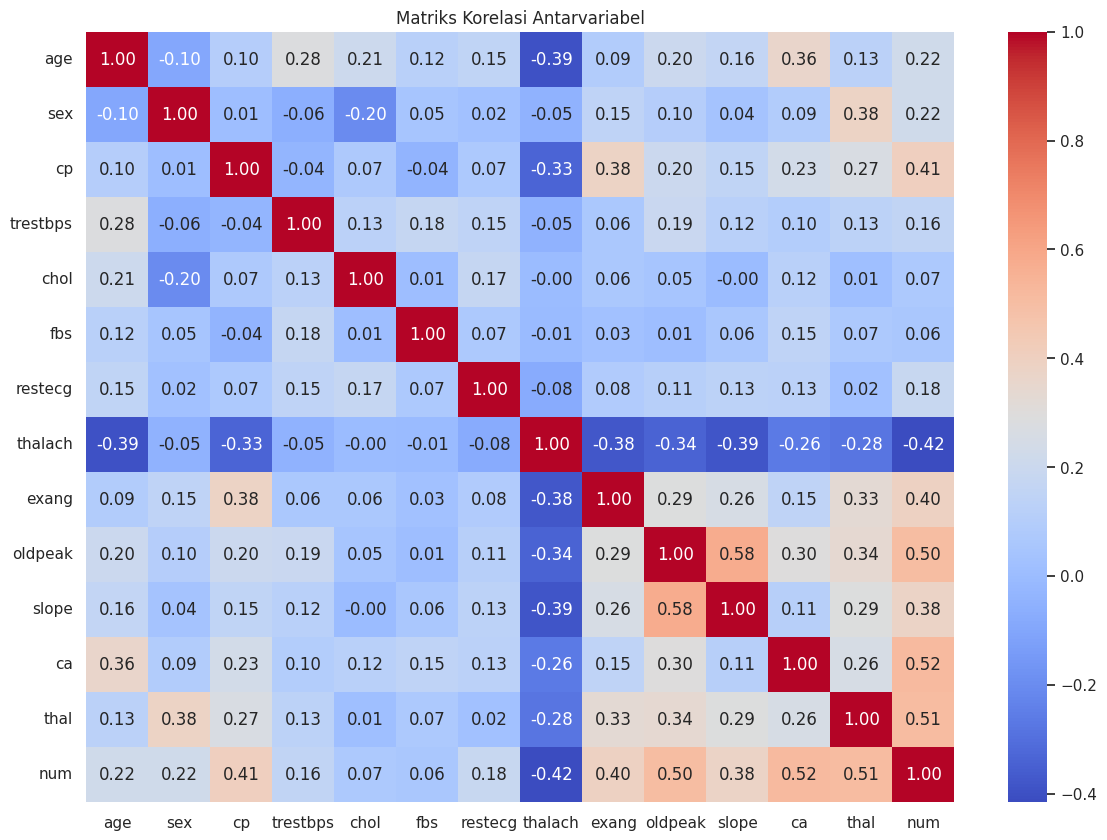

In [15]:
# Visualisasi korelasi antarvariabel
plt.figure(figsize=(14, 10))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matriks Korelasi Antarvariabel")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [17]:
# Membuat salinan dataset agar data mentah tetap aman
df_preprocessed = df.copy()

print("Ukuran dataset sebelum preprocessing:", df_preprocessed.shape)

Ukuran dataset sebelum preprocessing: (303, 14)


In [18]:
# Mengubah target menjadi klasifikasi biner
# 0 = tidak terindikasi penyakit jantung
# 1 = terindikasi penyakit jantung

df_preprocessed["target"] = (
    df_preprocessed["num"] > 0
).astype(int)

# Menghapus kolom target asli
df_preprocessed = df_preprocessed.drop(columns=["num"])

print("Distribusi target baru:")
print(df_preprocessed["target"].value_counts())

Distribusi target baru:
target
0    164
1    139
Name: count, dtype: int64


In [19]:
# Menghapus data duplikat
jumlah_data_sebelum = len(df_preprocessed)

df_preprocessed = df_preprocessed.drop_duplicates()

jumlah_data_sesudah = len(df_preprocessed)

print("Jumlah data sebelum menghapus duplikat:", jumlah_data_sebelum)
print("Jumlah data setelah menghapus duplikat:", jumlah_data_sesudah)
print(
    "Jumlah data duplikat yang dihapus:",
    jumlah_data_sebelum - jumlah_data_sesudah
)

Jumlah data sebelum menghapus duplikat: 303
Jumlah data setelah menghapus duplikat: 303
Jumlah data duplikat yang dihapus: 0


In [20]:
# Mengisi missing value menggunakan median setiap kolom
for column in df_preprocessed.columns:
    if df_preprocessed[column].isnull().sum() > 0:
        median_value = df_preprocessed[column].median()

        df_preprocessed[column] = (
            df_preprocessed[column]
            .fillna(median_value)
        )

print("Jumlah missing value setelah ditangani:")
print(df_preprocessed.isnull().sum())

Jumlah missing value setelah ditangani:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [21]:
# Menentukan fitur numerik kontinu yang akan distandardisasi
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Melakukan standardisasi
scaler = StandardScaler()

df_preprocessed[numerical_features] = scaler.fit_transform(
    df_preprocessed[numerical_features]
)

print("Standardisasi fitur numerik berhasil dilakukan.")

Standardisasi fitur numerik berhasil dilakukan.


In [22]:
# Memeriksa hasil akhir preprocessing
print("Ukuran akhir dataset:", df_preprocessed.shape)
print(
    "Total missing value:",
    df_preprocessed.isnull().sum().sum()
)
print(
    "Jumlah data duplikat:",
    df_preprocessed.duplicated().sum()
)

df_preprocessed.head()

Ukuran akhir dataset: (303, 14)
Total missing value: 0
Jumlah data duplikat: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.948726,1,1,0.757525,-0.264900,1,2,0.017197,0,1.087338,3,0.0,6.0,0
1,1.392002,1,4,1.611220,0.760415,0,2,-1.821905,1,0.397182,2,3.0,3.0,1
2,1.392002,1,4,-0.665300,-0.342283,0,2,-0.902354,1,1.346147,2,2.0,7.0,1
3,-1.932564,1,3,-0.096170,0.063974,0,0,1.637359,0,2.122573,3,0.0,3.0,0
4,-1.489288,0,2,-0.096170,-0.825922,0,2,0.980537,0,0.310912,1,0.0,3.0,0


In [23]:
# Membuat folder penyimpanan
os.makedirs(
    "heart_disease_preprocessing",
    exist_ok=True
)

# Menyimpan dataset hasil preprocessing
df_preprocessed.to_csv(
    "heart_disease_preprocessing/heart_disease_preprocessed.csv",
    index=False
)

print("Dataset hasil preprocessing berhasil disimpan.")

Dataset hasil preprocessing berhasil disimpan.


In [24]:
from google.colab import files

# Download dataset mentah
files.download(
    "heart_disease_raw/heart_disease_raw.csv"
)

# Download dataset hasil preprocessing
files.download(
    "heart_disease_preprocessing/heart_disease_preprocessed.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>